Zomato Dataset Rating Analysis

1.Import Necessary Libraries

In [34]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

 2.Load Dataset

In [35]:
df=pd.read_csv('zomato.csv')
df.shape

(51717, 17)

In [36]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [38]:
df.describe()

,votes
count,51717.000000
mean,283.697527
std,803.838853
min,0.000000
25%,7.000000
50%,41.000000
75%,198.000000
max,16832.000000


3.Data Cleaning 

In [39]:
# Clean 'rate' column (remove '/5' and non-numeric values)
df['rate'] = df['rate'].astype(str).str.replace('/5','').replace('NEW', np.nan).replace('-', np.nan)
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# Clean cost column (remove commas)
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str).str.replace(',', '')
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')

# Remove null values
df = df.dropna(subset=['rate', 'approx_cost(for two people)', 'votes'])

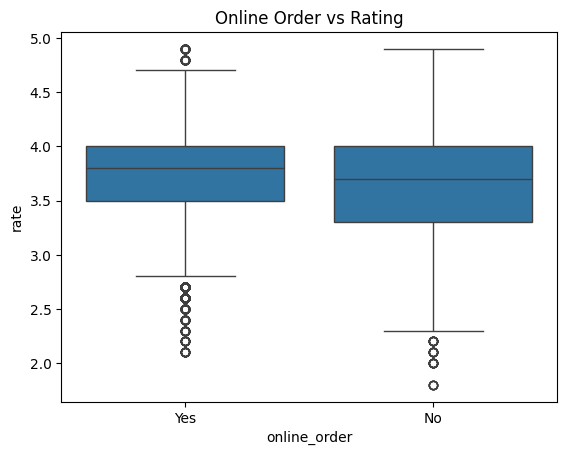

In [40]:
sns.boxplot(x='online_order',y='rate',data=df)
plt.title('Online Order vs Rating')
plt.show()

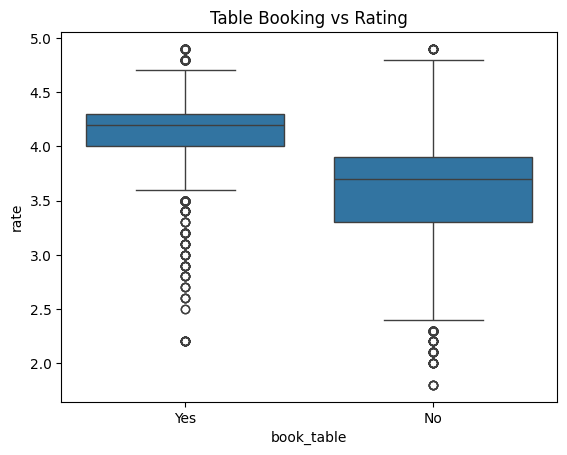

In [41]:
sns.boxplot(x='book_table',y='rate',data=df)
plt.title('Table Booking vs Rating')
plt.show()

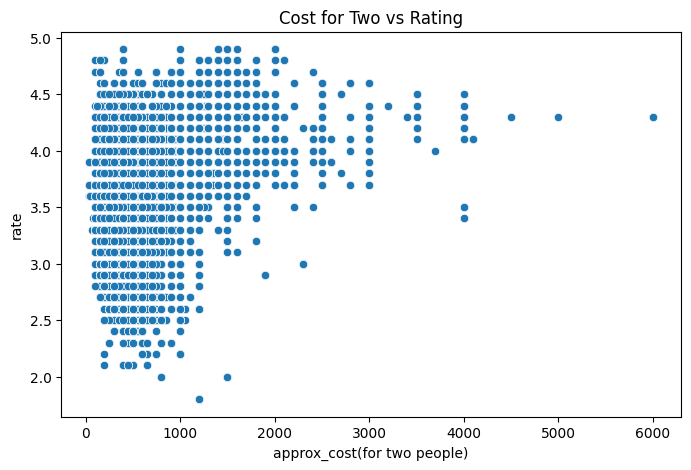

In [42]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='approx_cost(for two people)', y='rate', data=df)
plt.title("Cost for Two vs Rating")
plt.show()

In [43]:
df.rate

0        4.1
1        4.1
2        3.8
3        3.7
4        3.8
        ... 
51709    3.7
51711    2.5
51712    3.6
51715    4.3
51716    3.4
Name: rate, Length: 41418, dtype: float64

In [44]:
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                               0
votes                              0
phone                            578
location                           0
rest_type                        147
dish_liked                     18091
cuisines                           8
approx_cost(for two people)        0
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

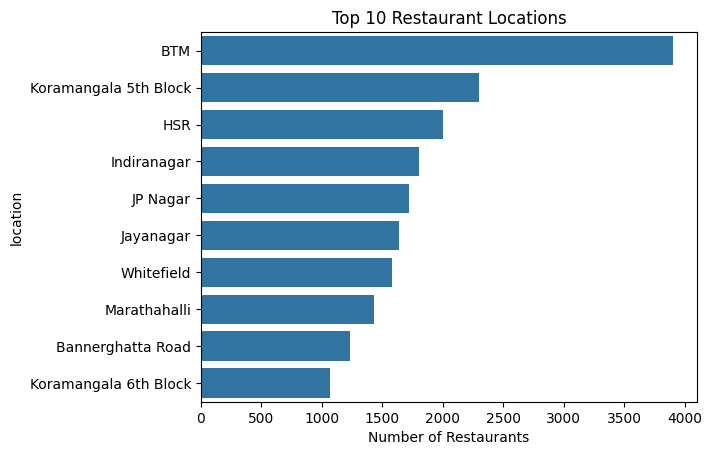

In [45]:
top_locations=df['location'].value_counts().head(10)
sns.barplot(x=top_locations.values, y=top_locations.index)
plt.title("Top 10 Restaurant Locations")
plt.xlabel("Number of Restaurants")
plt.show()

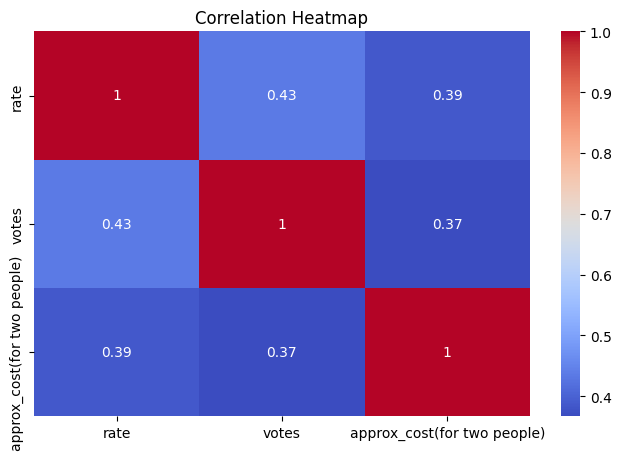

In [46]:
corr=df.corr(numeric_only=True)
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

  4.Feature Selection

In [47]:
features=['online_order','book_table','votes','approx_cost(for two people)','location','rest_type']
df=df[features + ['rate']]

In [48]:
df

,online_order,book_table,votes,approx_cost(for two people),location,rest_type,rate
0,Yes,Yes,775,800.0,Banashankari,Casual Dining,4.1
1,Yes,No,787,800.0,Banashankari,Casual Dining,4.1
2,Yes,No,918,800.0,Banashankari,"Cafe, Casual Dining",3.8
3,No,No,88,300.0,Banashankari,Quick Bites,3.7
4,No,No,166,600.0,Basavanagudi,Casual Dining,3.8
...,...,...,...,...,...,...,...
51709,No,No,34,800.0,Whitefield,"Casual Dining, Bar",3.7
51711,No,No,81,800.0,Whitefield,"Casual Dining, Bar",2.5
51712,No,No,27,1500.0,Whitefield,Bar,3.6
51715,No,Yes,236,2500.0,"ITPL Main Road, Whitefield",Bar,4.3


5.Create Ratings Category

In [49]:
def rating_category(x):
    if x <= 2.5:
        return 'Low'
    elif x <= 3.5:
        return 'Medium'
    else:
        return 'High'

df['rating_cat']=df['rate'].apply(rating_category)

  6.Convert catagorical column to numerical Column using LabelEncoder

In [50]:
label_cols=['online_order','book_table','location','rest_type']

for col in label_cols:
    df[col] = df[col].astype(str)
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

7.Define feautures(X) and Target(y)

In [51]:
X=df[['online_order','book_table','votes','approx_cost(for two people)','location','rest_type']]
y=df['rating_cat']

In [41]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

print("Train size:",X_train.shape,"Test Size:",X_test.shape)

Train size: (33134, 6) Test Size: (8284, 6)


In [42]:
lr=LogisticRegression(max_iter=5000)
lr.fit(X_train,y_train)
y_pred_lr=lr.predict(X_test)
print("Logistic Regression Accuracy:",accuracy_score(y_test,y_pred_lr))

Logistic Regression Accuracy: 0.7351521004345727


In [43]:
dt=DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:",accuracy_score(y_test,y_pred_dt))

Decision Tree Accuracy: 0.9556977305649444


In [44]:
rf=RandomForestClassifier(n_estimators=200,random_state=42)
rf.fit(X_train,y_train)
y_pred_rf=rf.predict(X_test)
print("Random Forest Accuracy:",accuracy_score(y_test,y_pred_rf))

Random Forest Accuracy: 0.9616127474649928


Classification Report (Random Forest):
              precision    recall  f1-score   support

        High       0.97      0.97      0.97      5367
         Low       0.97      0.87      0.92        77
      Medium       0.95      0.95      0.95      2840

    accuracy                           0.96      8284
   macro avg       0.96      0.93      0.94      8284
weighted avg       0.96      0.96      0.96      8284



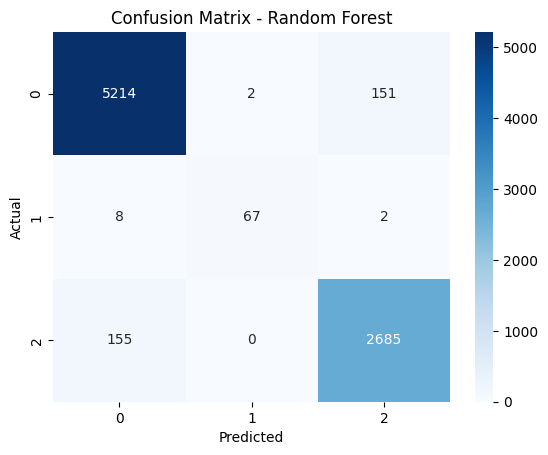

In [45]:
print("Classification Report (Random Forest):")
print(classification_report(y_test,y_pred_rf))

cm=confusion_matrix(y_test,y_pred_rf)
sns.heatmap(cm, annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [46]:
results=pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr),accuracy_score(y_test, y_pred_dt),accuracy_score(y_test, y_pred_rf)]
})
print(results.sort_values(by='Accuracy', ascending=False))

                 Model  Accuracy
2        Random Forest  0.961613
1        Decision Tree  0.955698
0  Logistic Regression  0.735152


In [47]:
# Model accuracies
models=['Logistic Regression','Decision Tree','Random Forest']
accuracy=[0.735152, 0.955698, 0.961613]

# Find index of the best model
best_index=accuracy.index(max(accuracy))

# Print best model and its accuracy
print("Best Model:",models[best_index])
print("Accuracy:",accuracy[best_index])

Best Model: Random Forest
Accuracy: 0.961613


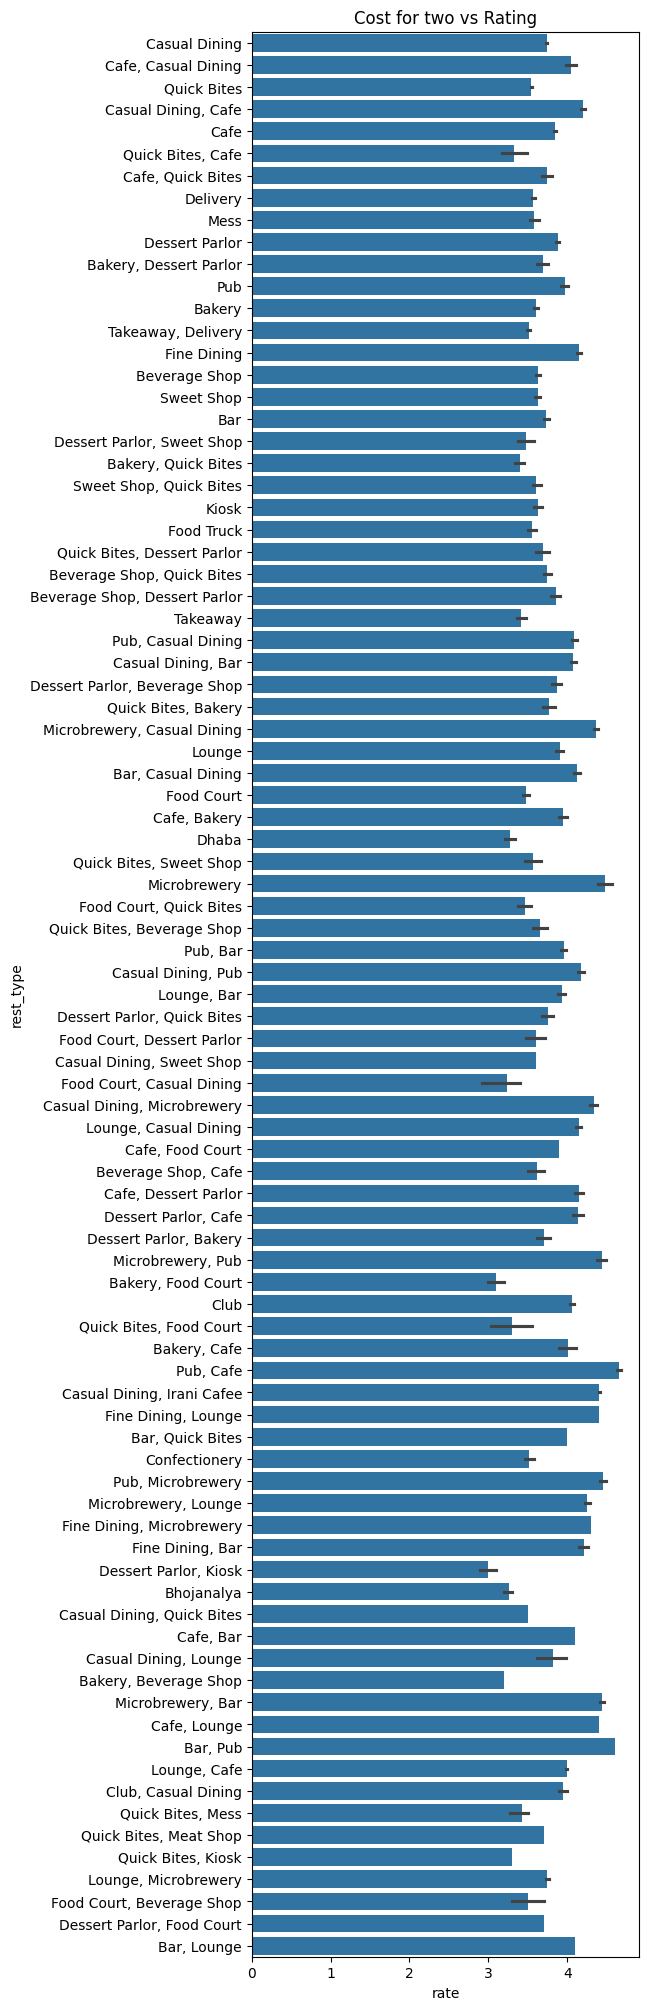

In [32]:
plt.figure(figsize=(5,25))
sns.barplot(y='rest_type',x='rate',data=df,estimator=np.mean)
plt.xticks(rotation=0)
plt.title('Cost for two vs Rating')
plt.show()